# Electrical Time Series Data Classification with FCN

## Prepare Notebook

In [1]:
import sys
from pathlib import Path

p = Path.cwd().resolve()
while p.name != "tinyml-timeseries" and p.parent != p:
    p = p.parent

REPO_ROOT = p
sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)
print("sys.path[0]:", sys.path[0])

REPO_ROOT: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries
sys.path[0]: /Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries


## Data Preparation

### Data Loading

In [2]:
import src.data.io as data_io
from src.data.split import stratified_split
from src.data.preprocessing import (
    clean_train_test,
    minmax_fit_transform_per_feature,
    one_hot_encode_labels,
)

# load
ed_data, ed_labels = data_io.load_data_sliding()

X_train, X_test, y_train, y_test = stratified_split(ed_data, ed_labels)
X_train, X_test = clean_train_test(X_train, X_test)
X_train, X_test, scalers = minmax_fit_transform_per_feature(X_train, X_test)

X_train_final, X_val, y_train_final, y_val = stratified_split(X_train, y_train)
y_train_final, y_val, y_test, num_classes = one_hot_encode_labels(
    y_train_final, y_val, y_test
)

print("\nFinal shapes:")
print("Train", X_train_final.shape)
print("Val", X_val.shape)
print("Test", X_test.shape)
print("Classes:", num_classes)

Stratified split successful
NaN & Inf values cleaned.
Data normalization complete (MinMax per feature).
Stratified split successful
One-hot encoding complete. Classes: 9

Final shapes:
Train (27105, 30, 5)
Val (6777, 30, 5)
Test (8471, 30, 5)
Classes: 9


### Dataset Size

In [3]:
import numpy as np

train_size_bytes = X_train_final.nbytes
print(f"Train Set Size in MB: {train_size_bytes / (1024 * 1024):.2f} MB")

Train Set Size in MB: 31.02 MB


## FCN Model

### Building

In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, GlobalAveragePooling1D, Dense
from tensorflow.keras.models import Model

def build_fcn(input_shape=(30, 5), num_classes=9):
    inputs = Input(shape=input_shape)

    x = Conv1D(filters=128, kernel_size=8, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters=256, kernel_size=5, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters=128, kernel_size=3, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = GlobalAveragePooling1D()(x)  # FCN’in temel özelliği GAP kullanımı

    outputs = Dense(num_classes, activation='softmax')(x)  # Yalnızca çıkış katmanı Dense olur

    model = Model(inputs, outputs)

    return model

fcn_model = build_fcn()

fcn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

fcn_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 30, 5)]           0         
                                                                 
 conv1d (Conv1D)             (None, 30, 128)           5248      
                                                                 
 batch_normalization (Batch  (None, 30, 128)           512       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 30, 128)           0         
                                                                 
 conv1d_1 (Conv1D)           (None, 30, 256)           164096    
                                                                 
 batch_normalization_1 (Bat  (None, 30, 256)           1024      
 chNormalization)                                            

In [5]:
from tensorflow.keras.utils import plot_model

plot_model(fcn_model, to_file="fcn_model.png", show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


### Training

In [6]:
from tensorflow.keras.callbacks import (
    EarlyStopping, 
    ReduceLROnPlateau, 
    ModelCheckpoint
)

def train_fcn(model, X_train, y_train, X_val, y_val,
              epochs=30, batch_size=32, save_best_model=True):
    callbacks = []

    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    callbacks.append(early_stopping)

    lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
    callbacks.append(lr_scheduler)

    if save_best_model:
        model_checkpoint = ModelCheckpoint("best_fcn_model.h5", save_best_only=True, monitor="val_loss")
        callbacks.append(model_checkpoint)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )

    return history

history = train_fcn(fcn_model,
                    X_train_final, y_train_final,
                    X_val, y_val,
                    epochs=50,
                    batch_size=32,
                    save_best_model=True)

Epoch 1/50
848/848 [==============================] - 7s 7ms/step - loss: 0.4744 - accuracy: 0.8331 - val_loss: 0.5008 - val_accuracy: 0.7804 - lr: 0.0010
Epoch 2/50
 25/848 [..............................] - ETA: 5s - loss: 0.3711 - accuracy: 0.8625

/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


848/848 [==============================] - 6s 7ms/step - loss: 0.3388 - accuracy: 0.8744 - val_loss: 0.5152 - val_accuracy: 0.7916 - lr: 0.0010
Epoch 3/50
848/848 [==============================] - 6s 7ms/step - loss: 0.2778 - accuracy: 0.8974 - val_loss: 0.3066 - val_accuracy: 0.8908 - lr: 0.0010
Epoch 4/50
848/848 [==============================] - 7s 8ms/step - loss: 0.2444 - accuracy: 0.9085 - val_loss: 0.2984 - val_accuracy: 0.8974 - lr: 0.0010
Epoch 5/50
848/848 [==============================] - 7s 8ms/step - loss: 0.2276 - accuracy: 0.9157 - val_loss: 0.2162 - val_accuracy: 0.9187 - lr: 0.0010
Epoch 6/50
848/848 [==============================] - 8s 9ms/step - loss: 0.1967 - accuracy: 0.9274 - val_loss: 0.3139 - val_accuracy: 0.8600 - lr: 0.0010
Epoch 7/50
848/848 [==============================] - 7s 8ms/step - loss: 0.1928 - accuracy: 0.9287 - val_loss: 0.1690 - val_accuracy: 0.9445 - lr: 0.0010
Epoch 8/50
848/848 [==============================] - 6s 8ms/step - loss: 0.1744 

## Evaluation

### Training Performance

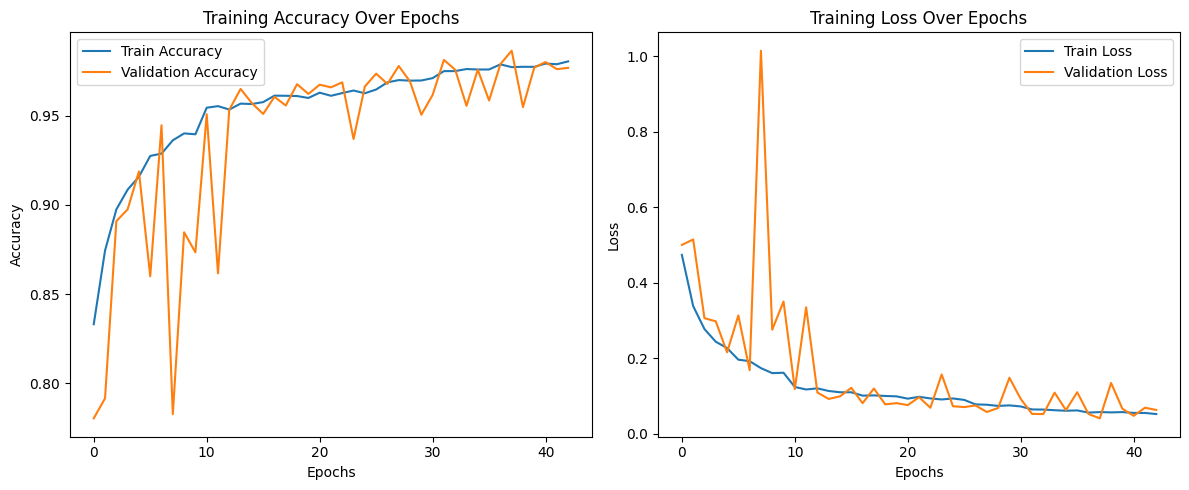

In [ ]:
from src.utils.visualization import plot_training_history

plot_training_history(history)

### Classification Metrics

265/265 [==============================] - 1s 2ms/step

Test Accuracy: 0.9889

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1789
           1     1.0000    1.0000    1.0000       188
           2     0.9940    0.9705    0.9821       508
           3     0.9672    0.9491    0.9581       373
           4     0.9927    0.9962    0.9944      2603
           5     0.9877    0.9969    0.9923      1938
           6     0.9808    1.0000    0.9903       511
           7     1.0000    0.7551    0.8605        98
           8     0.9446    0.9568    0.9506       463

    accuracy                         0.9889      8471
   macro avg     0.9852    0.9583    0.9698      8471
weighted avg     0.9890    0.9889    0.9887      8471



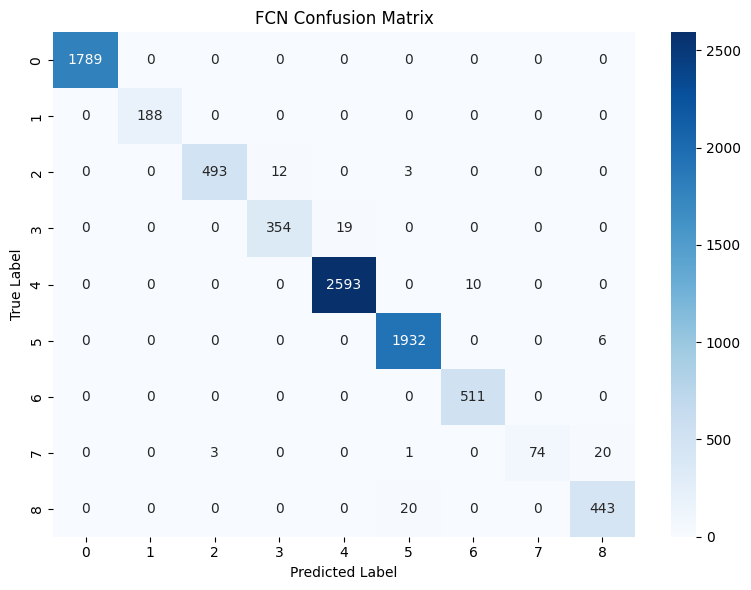

In [ ]:
from src.evaluation.metrics import (
    evaluate_classification,
    plot_confusion_matrix
)

accuracy, report, y_pred = evaluate_classification(
    fcn_model,
    X_test,
    y_test
)

y_true = y_test.argmax(axis=1)

cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="FCN Confusion Matrix"
)

### Model Saving and Size Check

In [14]:
import os

fcn_model.save("../../models/fcn_model.h5")

model_size = os.path.getsize("../../models/fcn_model.h5") / (1024 * 1024)
print(f"Real Model Size: {model_size:.2f} MB")

Real Model Size: 3.17 MB


/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## TinyML Performance

### TF Lite Conversion

In [15]:
converter = tf.lite.TFLiteConverter.from_keras_model(fcn_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

def representative_dataset():
    for sample in X_test.astype(np.float32):
        yield [np.expand_dims(sample, axis=0)]

converter.representative_dataset = representative_dataset

tflite_quantized_model = converter.convert()

with open("fcn_model_quantized.tflite", "wb") as f:
    f.write(tflite_quantized_model)

print("Quantized model saved: fcn_model_quantized.tflite")


INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpqv8s8a1s/assets


INFO:tensorflow:Assets written to: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpqv8s8a1s/assets
/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-02-25 21:27:39.315474: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-02-25 21:27:39.315484: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-02-25 21:27:39.315569: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2m/0nf612xs2c98c57_5dnh6kyr0000gn/T/tmpqv8s8a1s
2026-02-25 21:27:39.316613: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-02-25 21:27:39.316617: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/fold

Quantized model saved: fcn_model_quantized.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


### Evaluation

In [16]:
interpreter = tf.lite.Interpreter(model_path="fcn_model_quantized.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero_point = input_details[0]['quantization']
output_scale, output_zero_point = output_details[0]['quantization']

y_pred = []
y_true = np.argmax(y_test, axis=1)

for i in range(len(X_test)):
    test_sample = X_test[i:i+1] / input_scale + input_zero_point
    test_sample = np.round(test_sample).astype(np.int8)

    interpreter.set_tensor(input_details[0]['index'], test_sample)
    interpreter.invoke()

    output_data = interpreter.get_tensor(output_details[0]['index'])
    output_data = (output_data.astype(np.float32) - output_zero_point) * output_scale
    predicted_class = np.argmax(output_data)

    y_pred.append(predicted_class)

y_pred = np.array(y_pred)

print("TFLite model prediction completed on test set.")

TFLite model prediction completed on test set.


### Test Classification Report

In [17]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

classification_rep = classification_report(y_true, y_pred, digits=4)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_rep)

Test Accuracy: 0.9887
Precision: 0.9886
Recall: 0.9887
F1-score: 0.9884

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1789
           1     1.0000    1.0000    1.0000       188
           2     0.9920    0.9764    0.9841       508
           3     0.9697    0.9437    0.9565       373
           4     0.9923    0.9965    0.9944      2603
           5     0.9852    0.9969    0.9910      1938
           6     0.9827    1.0000    0.9913       511
           7     0.9726    0.7245    0.8304        98
           8     0.9546    0.9546    0.9546       463

    accuracy                         0.9887      8471
   macro avg     0.9832    0.9547    0.9669      8471
weighted avg     0.9886    0.9887    0.9884      8471



### Confusion Matrix

In [ ]:
cm = plot_confusion_matrix(
    y_true,
    y_pred,
    title="TFLite Model Confusion Matrix"
)

ImportError: cannot import name 'plot_confusion_matrix' from 'src.utils.visualization' (/Users/tolgareis/Documents/PhD/TinyML/tinyml-timeseries/src/utils/visualization.py)

### Model Size

In [ ]:
import os

tflite_model_path = "fcn_model_quantized.tflite"

tflite_model_size = os.path.getsize(tflite_model_path)

print(f"TFLite Model Size: {tflite_model_size / 1024:.2f} KB")

TFLite Model Size: 282.84 KB


### ESP32 Compatible Header File Creation

In [ ]:
import numpy as np

tflite_model_path = "fcn_model_quantized.tflite"
with open(tflite_model_path, "rb") as f:
    tflite_model = f.read()

c_array = ', '.join(str(b) for b in tflite_model)

header_text = f"""#ifndef FCN_MODEL_H
#define FCN_MODEL_H

alignas(8) const unsigned char fcn_model[] = {{
    {c_array}
}};

const unsigned int fcn_model_len = {len(tflite_model)};

#endif  // FCN_MODEL_H
"""

header_file_path = "fcn_model.h"
with open(header_file_path, "w") as f:
    f.write(header_text)

print(f"C++ header file created for ESP32: {header_file_path}")

C++ header file created for ESP32: fcn_model.h


### ESP32 Memory Results

In [ ]:
import pandas as pd

esp32_info = {
    "Parameter": [
        "CPU Cores",
        "CPU Frequency (MHz)",
        "Total Heap Memory (KB)",
        "Flash Memory Size (MB)"
    ],
    "Value": [
        2,
        240,
        355,
        4
    ]
}

df_esp32_info = pd.DataFrame(esp32_info)

df_esp32_info

### ESP32 Inference Results

In [ ]:
inference_results = {
    "Parameter": [
        "Model Input Scale",
        "Model Input Zero Point",
        "Model Output Scale",
        "Model Output Zero Point",
        "Prediction Result",
        "Model Prediction Class",
        "Inference Time (s)",
        "Model Memory Usage (KB)"
    ],
    "Value": [
        0.003955,
        -126,
        0.003906,
        -128,
        "0.000000, 0.000000, 0.187500, 0.789062, 0.000000, 0.000000, 0.023437, 0.000000, 0.000000, 0.000000",
        3,
        0.53,
        20.65
    ]
}

df_inference_results = pd.DataFrame(inference_results)

df_inference_results

,Parameter,Value
0,Model Input Scale,0.003955
1,Model Input Zero Point,-126
2,Model Output Scale,0.003906
3,Model Output Zero Point,-128
4,Prediction Result,"0.000000, 0.000000, 0.187500, 0.789062, 0.0000..."
5,Model Prediction Class,3
6,Inference Time (s),0.53
7,Model Memory Usage (KB),20.65
